<a href="https://colab.research.google.com/github/nourmoustafax/Market-Analysis/blob/main/Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv('/content/three_keywords.csv')
df = pd.read_csv('/content/three_keywords_geo.csv')
df = pd.read_csv('/content/workout.csv')
df = pd.read_csv('/content/workout_geo.csv')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd

df_workout = pd.read_csv('workout.csv')
df_keywords = pd.read_csv('three_keywords.csv')
df_workout_geo = pd.read_csv('workout_geo.csv')
df_keywords_geo = pd.read_csv('three_keywords_geo.csv')

df_workout['month'] = pd.to_datetime(df_workout['month'])
df_keywords['month'] = pd.to_datetime(df_keywords['month'])

df_workout_geo['workout_2018_2023'] = df_workout_geo['workout_2018_2023'].fillna(0)
df_keywords_geo = df_keywords_geo.fillna(0)

df_workout = df_workout.drop_duplicates()
df_keywords = df_keywords.drop_duplicates()
df_workout_geo = df_workout_geo.drop_duplicates()
df_keywords_geo = df_keywords_geo.drop_duplicates()

print("--- Data Quality Check ---")
print(f"Total missing values in workout: {df_workout.isnull().sum().sum()}")
print(f"Month column data type: {df_workout['month'].dtype}")

df_workout.to_csv('workout_cleaned.csv', index=False)
df_keywords.to_csv('three_keywords_cleaned.csv', index=False)
df_workout_geo.to_csv('workout_geo_cleaned.csv', index=False)
df_keywords_geo.to_csv('three_keywords_geo_cleaned.csv', index=False)

print("\nData cleaning complete. Cleaned files saved.")

--- Data Quality Check ---
Total missing values in workout: 0
Month column data type: datetime64[ns]

Data cleaning complete. Cleaned files saved.


### Rank Countries by Search Interest

In [9]:
df_keywords_geo = df_keywords_geo.rename(columns={'Country': 'country'})

df_geo_combined = pd.merge(
    df_workout_geo,
    df_keywords_geo,
    on='country',
    how='outer'
)

df_geo_combined = df_geo_combined.fillna(0)

df_geo_combined['total_search_interest'] = (
    df_geo_combined['workout_2018_2023'] +
    df_geo_combined['home_workout_2018_2023'] +
    df_geo_combined['gym_workout_2018_2023']
)

df_ranked_countries = df_geo_combined.sort_values(
    by='total_search_interest',
    ascending=False
)

display(df_ranked_countries.head(10))

,country,workout_2018_2023,home_workout_2018_2023,gym_workout_2018_2023,home_gym_2018_2023,total_search_interest
237,United States,100.0,36.0,27.0,37.0,163.0
174,Philippines,69.0,52.0,38.0,10.0,159.0
38,Canada,86.0,40.0,27.0,33.0,153.0
156,New Zealand,73.0,34.0,36.0,30.0,143.0
191,Singapore,66.0,37.0,39.0,24.0,142.0
12,Australia,77.0,30.0,34.0,36.0,141.0
106,Ireland,69.0,33.0,36.0,31.0,138.0
236,United Kingdom,66.0,34.0,36.0,30.0,136.0
235,United Arab Emirates,56.0,32.0,47.0,21.0,135.0
165,Norway,44.0,50.0,35.0,15.0,129.0


/tmp/ipykernel_483/2814371067.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


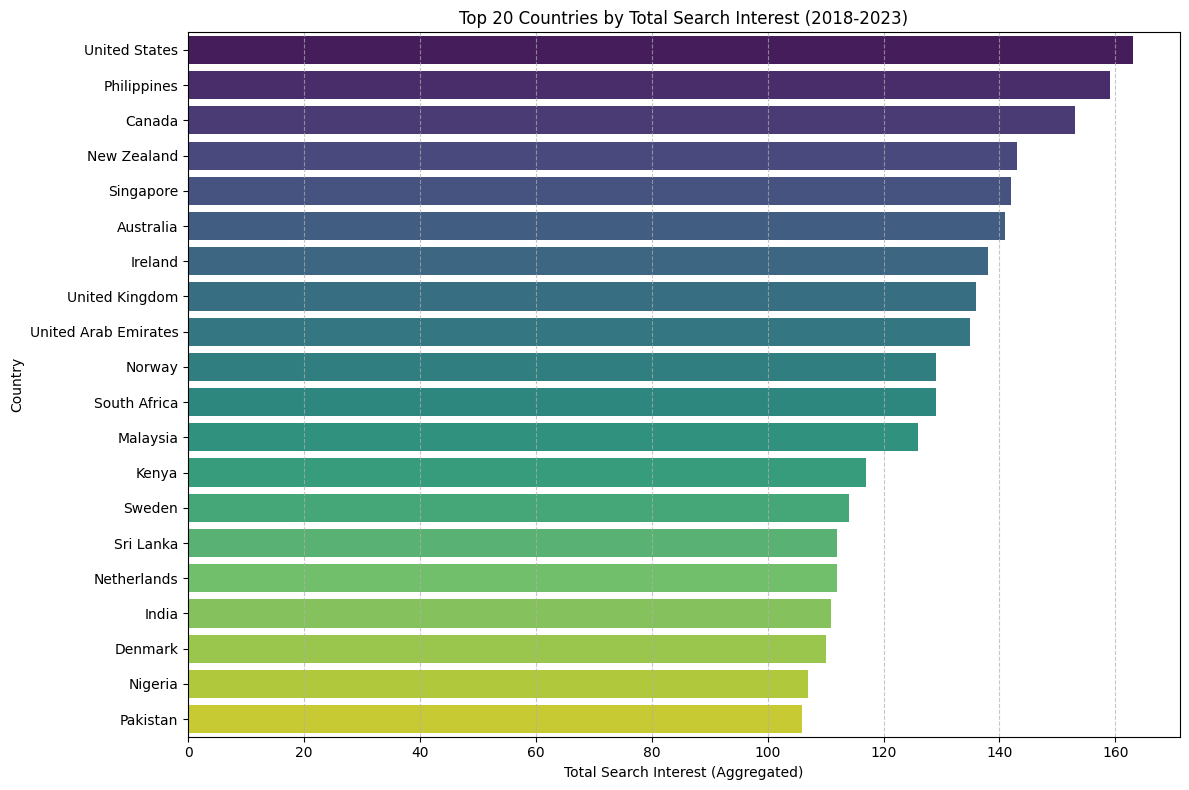

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 20 countries for plotting
top_countries = df_ranked_countries.head(20)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='total_search_interest',
    y='country',
    data=top_countries,
    palette='viridis'
)
plt.title('Top 20 Countries by Total Search Interest (2018-2023)')
plt.xlabel('Total Search Interest (Aggregated)')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

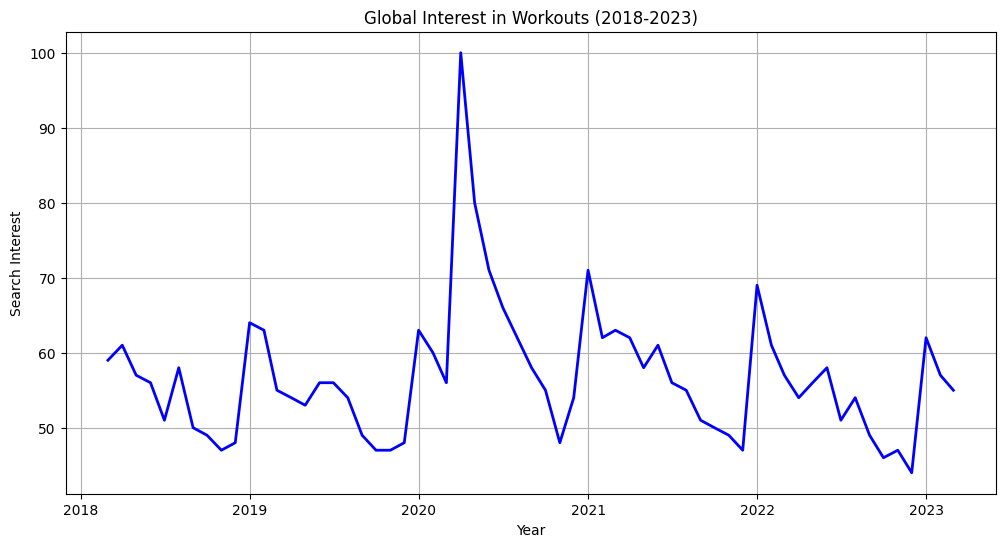

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_workout['month'], df_workout['workout_worldwide'], color='blue', linewidth=2)
plt.title('Global Interest in Workouts (2018-2023)')
plt.xlabel('Year')
plt.ylabel('Search Interest')
plt.grid(True)
plt.show()



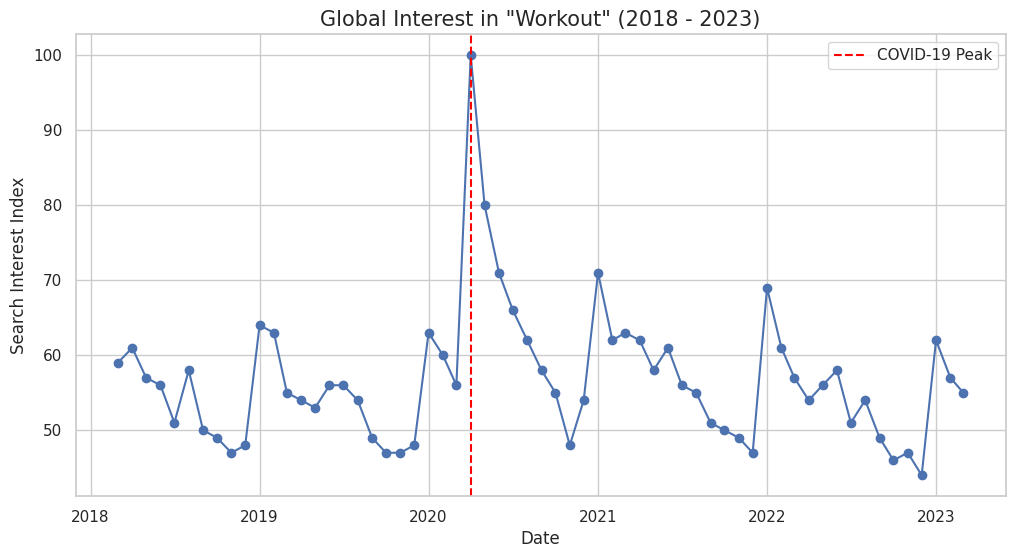

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")

# 1. Plotting Global Workout Trends (The "Pulse")
plt.figure(figsize=(12, 6))
plt.plot(df_workout['month'], df_workout['workout_worldwide'], marker='o', linestyle='-', color='b')
plt.title('Global Interest in "Workout" (2018 - 2023)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Search Interest Index')
plt.axvline(pd.to_datetime('2020-04-01'), color='red', linestyle='--', label='COVID-19 Peak') # Highlighting the peak
plt.legend()
plt.show()

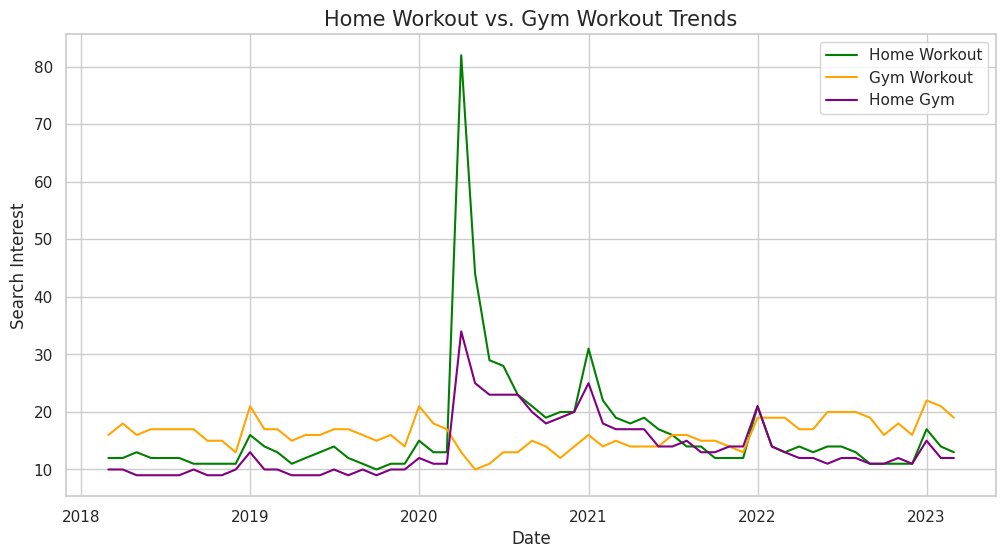

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")

# 2. Comparing Home vs Gym vs Home Gym
plt.figure(figsize=(12, 6))
plt.plot(df_keywords['month'], df_keywords['home_workout_worldwide'], label='Home Workout', color='green')
plt.plot(df_keywords['month'], df_keywords['gym_workout_worldwide'], label='Gym Workout', color='orange')
plt.plot(df_keywords['month'], df_keywords['home_gym_worldwide'], label='Home Gym', color='purple')
plt.title('Home Workout vs. Gym Workout Trends', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Search Interest')
plt.legend()
plt.show()



/tmp/ipykernel_483/3824891556.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_home_workout, x='home_workout_2018_2023', y='country', palette='viridis')


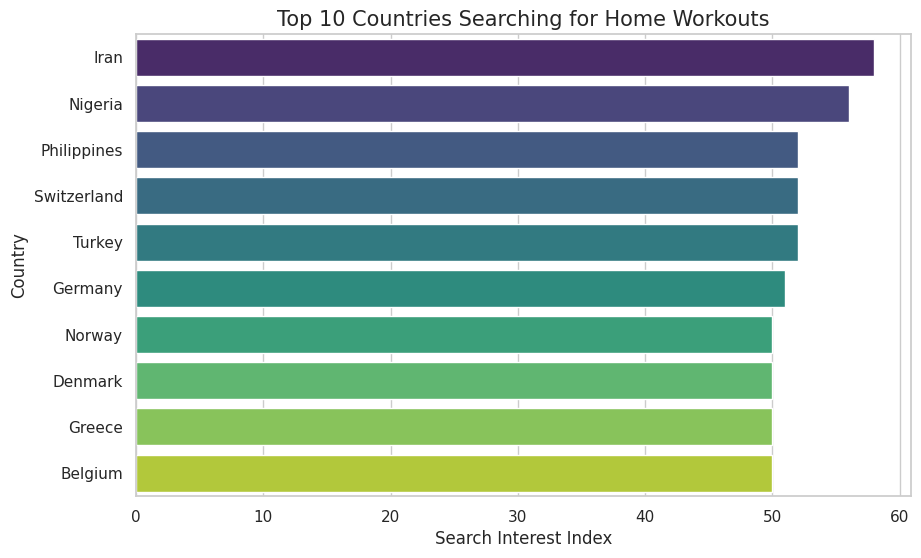

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")

# 3. Top 10 Countries for Home Workouts (Target Markets)
# We sort by home_workout_2018_2023 and take the top 10
top_10_home_workout = df_keywords_geo.sort_values('home_workout_2018_2023', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_home_workout, x='home_workout_2018_2023', y='country', palette='viridis')
plt.title('Top 10 Countries Searching for Home Workouts', fontsize=15)
plt.xlabel('Search Interest Index')
plt.ylabel('Country')
plt.show()

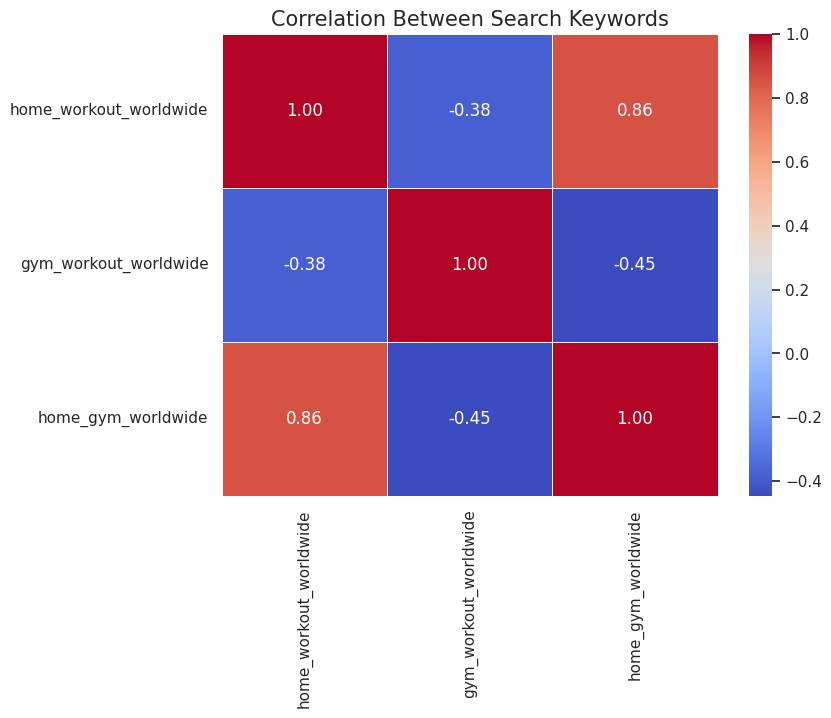

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix for the keywords
# This measures how closely related the search volumes are
correlation_matrix = df_keywords[['home_workout_worldwide', 'gym_workout_worldwide', 'home_gym_worldwide']].corr()

# 2. Create a Heatmap to visualize the correlation
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Search Keywords', fontsize=15)
plt.show()